In [170]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e12/sample_submission.csv
/kaggle/input/playground-series-s5e12/train.csv
/kaggle/input/playground-series-s5e12/test.csv


In [171]:
import pandas as pd
import numpy as np
import tensorflow as tf
# from tensorflow.keras import 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import 
from sklearn.metrics import classification_report, confusion_matrix

In [172]:
traind=pd.read_csv("/kaggle/input/playground-series-s5e12/train.csv")
testd=pd.read_csv("/kaggle/input/playground-series-s5e12/test.csv")
submissionformat=pd.read_csv("/kaggle/input/playground-series-s5e12/sample_submission.csv")

In [173]:
traind.head(5)

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [174]:
traind.columns

Index(['id', 'age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'gender', 'ethnicity', 'education_level',
       'income_level', 'smoking_status', 'employment_status',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'diagnosed_diabetes'],
      dtype='object')

In [175]:
traind.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                

In [176]:
traind.isnull().sum()

id                                    0
age                                   0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
smoking_status                        0
employment_status                     0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0


In [177]:
for column in traind:
   print(f"{column}-{traind[column].unique()}")

id-[     0      1      2 ... 699997 699998 699999]
age-[31 50 32 54 42 41 51 34 44 47 63 40 57 49 43 70 53 45 59 52 73 61 33 38
 20 56 46 48 62 39 36 21 22 55 30 67 25 60 28 26 65 74 37 68 23 58 84 27
 64 66 35 72 29 79 75 80 71 77 24 78 69 19 82 81 76 83 87 85 86 88 89]
alcohol_consumption_per_week-[1 2 3 4 5 6 7 8 9]
physical_activity_minutes_per_week-[ 45  73 158  77  55 100 148 102  44  36 239  58 109 251  57  99  53  54
  94  29  72  46  52 118  82 140  47  59  92  32  28  70  34  83  91  98
 217  84 135  41  43 113  90  37 142 174 144 196   4  42 166  65  85 194
 110  64  48  30  40 130  31  13 141  50 105  78 237  96  74  49  81 337
  14 126  61 101  63 112  39 139 122  89  76  23  25 183  56 117 115  51
  80  95 275 120  69  26  27  60  75  88 111  66 405 311  79  24  86 199
  87  71  67 226 178 103 106  93  68  16  35 131  97  38  62 328 181 104
 376 125 127 137 107 208 202 219 121  17 108  19 150 224  10 163 133  18
 324 129 227 281 155 256  11  33 268 116  20 396 161  21 263

In [178]:
traind.drop("id",axis=1, inplace=True)

In [179]:
testd.drop("id",axis=1, inplace=True)

In [180]:
traind.head(5)

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,70,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,77,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,89,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,69,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,60,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [181]:
traind=pd.get_dummies(data=traind,columns=['gender','ethnicity','education_level','income_level','smoking_status','employment_status','alcohol_consumption_per_week'])
testd=pd.get_dummies(data=testd,columns=['gender','ethnicity','education_level','income_level','smoking_status','employment_status','alcohol_consumption_per_week'])

In [182]:
traind.replace(True,1,inplace=True)
traind.replace(False,0,inplace=True)
testd.replace(True,1,inplace=True)
testd.replace(False,0,inplace=True)

/tmp/ipykernel_55/2304492213.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  traind.replace(False,0,inplace=True)
/tmp/ipykernel_55/2304492213.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  testd.replace(False,0,inplace=True)


In [183]:
traind.head(5)

,age,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,...,employment_status_Unemployed,alcohol_consumption_per_week_1,alcohol_consumption_per_week_2,alcohol_consumption_per_week_3,alcohol_consumption_per_week_4,alcohol_consumption_per_week_5,alcohol_consumption_per_week_6,alcohol_consumption_per_week_7,alcohol_consumption_per_week_8,alcohol_consumption_per_week_9
0,31,45,7.7,6.8,6.1,33.4,0.93,112,70,62,...,0,1,0,0,0,0,0,0,0,0
1,50,73,5.7,6.5,5.8,23.8,0.83,120,77,71,...,0,0,1,0,0,0,0,0,0,0
2,32,158,8.5,7.4,9.1,24.1,0.83,95,89,73,...,0,0,0,1,0,0,0,0,0,0
3,54,77,4.6,7.0,9.2,26.6,0.83,121,69,74,...,0,0,0,1,0,0,0,0,0,0
4,54,55,5.7,6.2,5.1,28.8,0.90,108,60,85,...,0,1,0,0,0,0,0,0,0,0


In [184]:
traind.shape

(700000, 51)

In [185]:
testd.shape

(300000, 50)

In [186]:
traind.columns

Index(['age', 'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'diagnosed_diabetes', 'gender_Female',
       'gender_Male', 'gender_Other', 'ethnicity_Asian', 'ethnicity_Black',
       'ethnicity_Hispanic', 'ethnicity_Other', 'ethnicity_White',
       'education_level_Graduate', 'education_level_Highschool',
       'education_level_No formal', 'education_level_Postgraduate',
       'income_level_High', 'income_level_Low', 'income_level_Lower-Middle',
       'income_level_Middle', 'income_level_Upper-Middle',
       'smoking_status_Current', 'smoking_status_Former',
       'smoking_status_Never', 'employment_status_Employed',
       'employment_status_Retired', 'employment_st

In [187]:
y=traind["diagnosed_diabetes"]

In [188]:
x=traind.drop(columns="diagnosed_diabetes")


In [189]:
X_train, X_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [190]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [191]:
from tensorflow import keras
from tensorflow.keras.layers import BatchNormalization

In [192]:
model=keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(256,activation="relu"),
    BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128,activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64,activation="relu"),
    keras.layers.Dense(1,activation="sigmoid"),
])

In [193]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [194]:
model.fit(X_train,y_train,epochs=20,batch_size=500)

Epoch 1/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6346 - loss: 0.6317
Epoch 2/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.6589 - loss: 0.6080
Epoch 3/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.6615 - loss: 0.6052
Epoch 4/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.6637 - loss: 0.6038
Epoch 5/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.6617 - loss: 0.6047
Epoch 6/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6629 - loss: 0.6047
Epoch 7/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6634 - loss: 0.6040
Epoch 8/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6635 - loss: 0.6034
Epoch 9/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6633 - loss: 0.6035
Epoch 10/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6626 - loss: 0.6037
Epoch 11/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.6630 - loss: 0.6039
Epoch 12/20
1120/1120 ━━━━━━━

In [195]:
model.evaluate(X_test,y_test)

4375/4375 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.6634 - loss: 0.6029


[0.6033748388290405, 0.6635785698890686]

In [196]:
yp=model.predict(X_test)

4375/4375 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step


In [197]:
yp

array([[0.839086  ],
       [0.48896876],
       [0.42740703],
       ...,
       [0.8502937 ],
       [0.87688136],
       [0.75604385]], dtype=float32)

4375/4375 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step


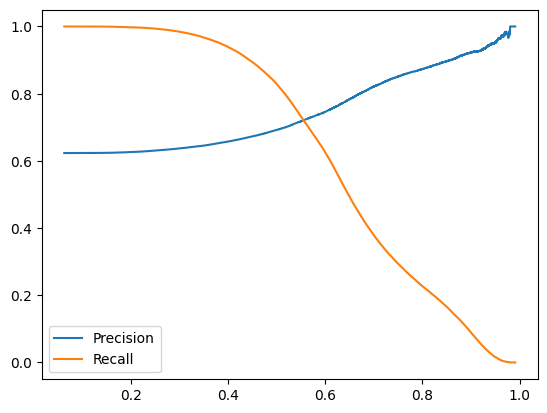

In [198]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

probs = model.predict(X_test)

precision, recall, thresholds = precision_recall_curve(y_test, probs)

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.legend()
plt.show()

In [199]:
y_pred=[]
for i in yp:
    if i>0.6:
        y_pred.append(1)
    else:
        y_pred.append(0)

In [200]:
y_pred[:10]

[1, 0, 0, 0, 1, 1, 1, 0, 1, 0]

In [201]:
output=pd.DataFrame({
    "Actual values":y_test,
    "Predicted Values":y_pred,
    "Correct?":y_test==y_pred
})

In [202]:
output.head(5)

,Actual values,Predicted Values,Correct?
7760,1.0,1,True
594954,0.0,0,True
480236,0.0,0,True
26944,1.0,0,False
616593,1.0,1,True


In [203]:
output["Correct?"].value_counts()

Correct?
True     88732
False    51268
Name: count, dtype: int64

In [204]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.65      0.51      0.57     66819
           1       0.63      0.75      0.68     73181

    accuracy                           0.63    140000
   macro avg       0.64      0.63      0.63    140000
weighted avg       0.64      0.63      0.63    140000



<Axes: >

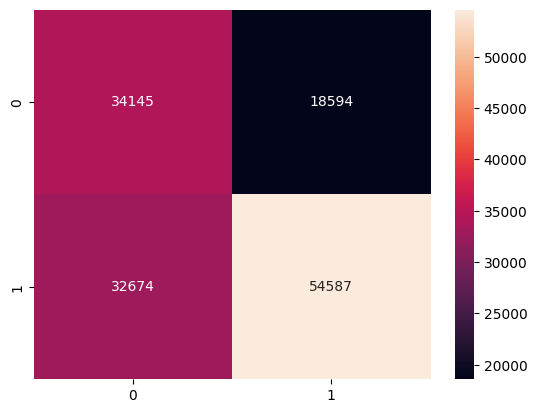

In [205]:
cm=tf.math.confusion_matrix(y_test,predictions=y_pred)
sns.heatmap(cm,annot=True,fmt='d')

In [212]:
import pandas as pd

# Load test
test = pd.read_csv("/kaggle/input/playground-series-s5e12/test.csv")

# Save ID
test_ids = test["id"]

# Drop id
test = test.drop(columns=["id"])

# Apply same encoding
test = pd.get_dummies(test, drop_first=True)

# Align columns with training data
test = test.reindex(columns=X_train.columns, fill_value=0)

# Scale
test = scaler.transform(test)

# Predict
y_pred = model.predict(test).flatten()

# Create submission
submission = pd.DataFrame({
    "id": test_ids,
    "Heart Disease": y_pred
})

submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully.")

AttributeError: 'numpy.ndarray' object has no attribute 'columns'